#Importamos las librerías necesarias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

#Importamos el dataset desde el repositorio de la UCI

In [3]:
# Descargar los datos con pandas
df_red = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')

df_white = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',sep=';')

df = pd.concat([df_red, df_white])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#EDA - Analisis esploratorio

In [4]:
#EDA Básico

df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 659.9 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Tenemos solo valores númericos y sin nulos

In [ ]:
#Usaremos la función de pandas describe para obtener un análisis estadistico de las variables
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Notamos que no hay nulos o nulos escondidos en el dataset, analizemos de forma gráfica las distribuciones de las variables para encontrar posibles outliers

In [5]:

for col in df.select_dtypes(include='number').columns:
    fig = px.histogram(df, x=col, nbins=15, title=f'Distribución de {col}', color_discrete_sequence=['teal'])
    fig.show()


SI existen outliers en las variables como residual sugar y sulfur dioxide

Al existir outliers o valores atipicos se pueden tomar 2 caminos

Eliminar los registros del dataset, si la incidencia es baja
Imputar el valor, es decir reemplazarlo, ya sea por la media, mediana o algun percentil

¿Que haremos? yo siempre recomiendo no dejar de lado ninguna información, sobre todo en datasets pequeños, asi que imputaremos, usando la mediana

In [6]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana


In [7]:
#Validamos los distribución sin outliers


for col in df_outliers.select_dtypes(include='number').columns:
    fig = px.histogram(df_outliers, x=col, nbins=15, title=f'Distribución de {col}', color_discrete_sequence=['teal'])
    fig.show()

Una vez que ya tenemos las variables sin nulos ni outliers, lo siguiente es analizar la variable objetivo, como comentamos queremos predecir si el vino es de alta calidad o no, por tanto necesitamos primero definir a partir de la variable quality, que será alta calidad

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


/tmp/ipython-input-7320980.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




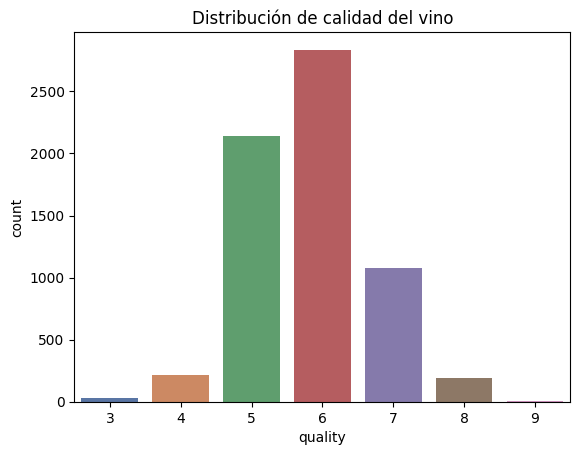

In [8]:
# Distribución de calidad
print(df['quality'].value_counts().sort_index())
sns.countplot(x='quality', data=df, palette='deep')
plt.title("Distribución de calidad del vino")
plt.show()

Vemos que aunque quality tenia según la documentación valores de 1 al 10, en realidad tiene valores de 3 a 9, teniendo la moda en el 6, asi que podemos considerar que el numero 6 sería la calidad standar, y los que esté arriba del numero 6 sería una calidad alta, así que un vino de calidad alta será aquel con calificación de 7 o superior

In [9]:
df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df_target_b.head()

,quality
0,0
1,0
2,0
3,0
4,0


/tmp/ipython-input-1471937934.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




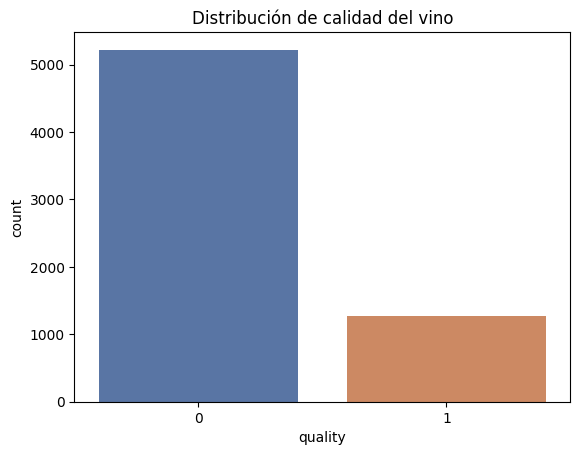

In [10]:
sns.countplot(x=df_target_b, palette='deep')
plt.title("Distribución de calidad del vino")
plt.xlabel("quality")
plt.show()


In [11]:
#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [12]:
df_limpio.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.139149,0.334288,0.317028,5.424765,0.052353,30.376635,115.695013,0.994690,3.218255,0.526777,10.491801,0.196552
std,1.120806,0.153285,0.141185,4.676288,0.020918,17.146912,56.378478,0.002948,0.160186,0.134871,1.192712,0.397421
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,0.000000
75%,7.600000,0.400000,0.390000,8.100000,0.062000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,0.000000
max,11.600000,0.910000,0.810000,26.050000,0.146000,112.000000,366.500000,1.010300,3.900000,1.100000,14.900000,1.000000


#Correlaciones

Validaremos si no hay correlaciones en las variables que puedan generar ruido al modelo

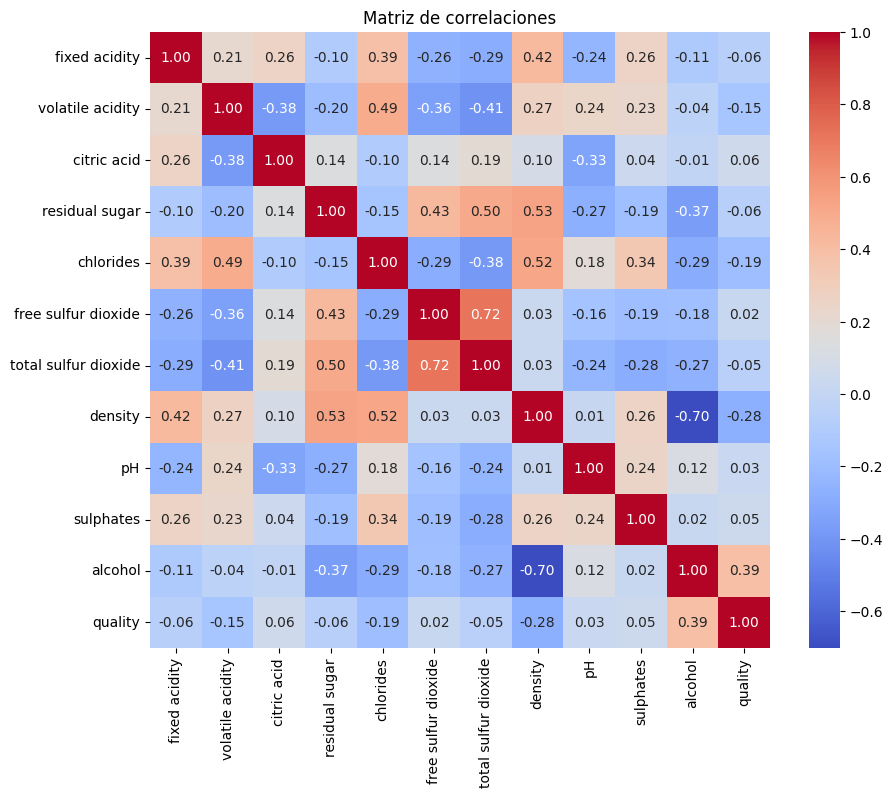

In [ ]:
# Matrix de Correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()


Hay algunas correlaciones pero que no son fuertes, dejemos todas las variables para ver como se comporta el modelo

Tambien podemos anticipar que hay una correlación entre alcohol y calidad, aunque no muy fuerte, esto indicaría que es una variable relevante en el modelo

#Empecemos a modelar

In [18]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality','density','free sulfur dioxide'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30


In [19]:
#Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


#Evaluación del modelo

In [20]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1048
           1       0.82      0.59      0.69       252

    accuracy                           0.90      1300
   macro avg       0.86      0.78      0.81      1300
weighted avg       0.89      0.90      0.89      1300



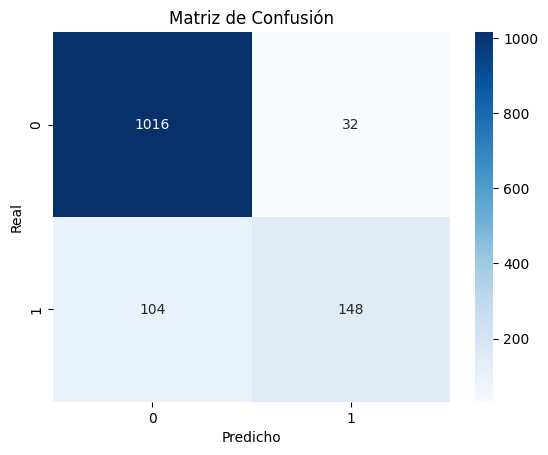

In [21]:
# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


In [22]:
#curva ROC
y_probs = model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva (vino de calidad alta)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()



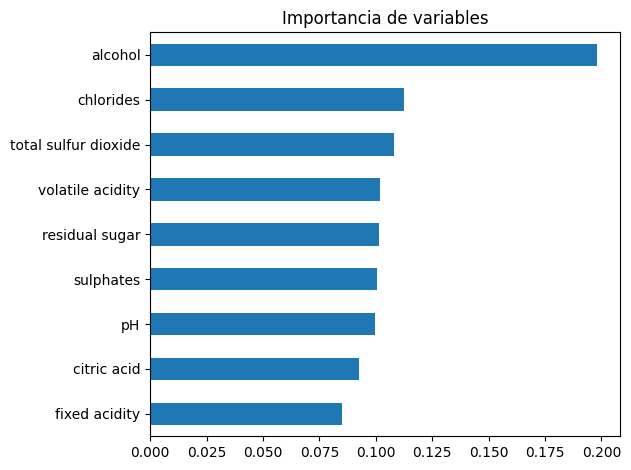

In [23]:
# Importancia de variables
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Importancia de variables')
plt.tight_layout()
plt.show()
